# 23. Contract directional feedback prototype

Минимальная проверка rule-based feedback поверх `z_contract`: feedback меняет не EQ напрямую, а пользовательский вектор, который затем проходит через mapper.

In [1]:

from personalization.plotting import use_article_style
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
METRICS_DIR = OUTPUT_DIR / "metrics"
TABLES_DIR = OUTPUT_DIR / "tables"
for p in [FIGURES_DIR, METRICS_DIR, TABLES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from personalization.state import FEATURE_NAMES_8D
from personalization.contract_space import (
    DEFAULT_CONTRACT_SCALE,
    CONTRACT_ARCHETYPES_8D,
    archetype_table,
    contract_scale_table,
    make_axis_sweep_contract,
    z_contract_series,
)
from personalization.contract_mapper import InterpretableContractMapper8D, FREQS_23_DEFAULT
from personalization.contract_metrics import curve_metrics, mapped_pair_metrics, mapped_distance_to_target


def plot_eq_curves(curves, freqs=FREQS_23_DEFAULT, title=None):
    fig, ax = plt.subplots(figsize=(13, 5))
    for label, curve in curves.items():
        ax.plot(freqs, curve, marker="o", linewidth=1.6, label=label)
    ax.axhline(0, linewidth=1, alpha=0.35)
    ax.set_xscale("log")
    ax.set_xticks(freqs)
    ax.set_xticklabels([f"{f:g}" for f in freqs], rotation=45, ha="right")
    ax.set_xlabel("Frequency, Hz")
    ax.set_ylabel("Gain, dB")
    if title:
        ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")
    plt.tight_layout()
    return fig, ax


def savefig(name):
    path = FIGURES_DIR / name
    plt.savefig(path, dpi=180, bbox_inches="tight")
    print("saved:", path)

from personalization.contract_feedback import (
    feedback_labels_table,
    apply_feedback_to_z,
    apply_feedback_to_state,
)
from personalization.state import init_preference_state

use_article_style()


## Feedback labels

In [2]:
feedback_labels_table()

,feedback_label,sub_bass,bass,lowmid,warmth,presence,clarity,air,brightness
0,too_much_bass,-0.16,-0.22,-0.05,0.00,0.00,0.00,0.00,0.08
1,not_enough_bass,0.16,0.22,0.03,0.00,0.00,0.00,0.00,-0.05
2,too_bright,0.02,0.03,0.02,0.03,-0.06,-0.12,-0.18,-0.22
3,too_dark,-0.02,-0.02,-0.02,-0.03,0.06,0.12,0.18,0.22
4,too_muddy,0.00,-0.06,-0.18,-0.12,0.04,0.08,0.03,0.08
5,too_thin,0.08,0.12,0.12,0.10,-0.02,-0.02,0.00,-0.04
6,more_presence,0.00,0.00,-0.03,0.00,0.18,0.08,0.00,0.05
7,less_presence,0.00,0.00,0.03,0.00,-0.18,-0.08,0.00,-0.05
8,more_air,0.00,0.00,0.00,0.00,0.02,0.08,0.22,0.12
9,less_air,0.00,0.00,0.00,0.00,-0.02,-0.08,-0.22,-0.12


## One-profile feedback example

saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\notebooks\outputs\figures\v6_contract_feedback_sequence.png


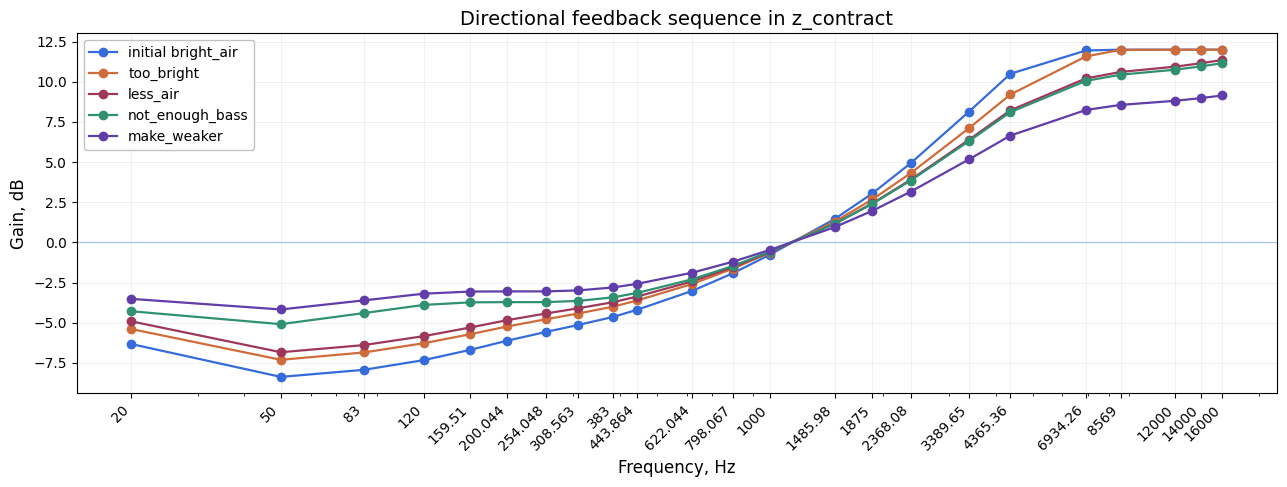

,stage,z_max_abs,sub_bass,bass,lowmid,warmth,presence,clarity,air,brightness
0,initial bright_air,1.550,-0.3500,-0.25,-0.350,-0.2000,0.5500,1.100,1.550,1.3500
1,too_bright,1.370,-0.3300,-0.22,-0.330,-0.1700,0.4900,0.980,1.370,1.1300
2,less_air,1.150,-0.3300,-0.22,-0.330,-0.1700,0.4700,0.900,1.150,1.0100
3,not_enough_bass,1.150,-0.1700,0.00,-0.300,-0.1700,0.4700,0.900,1.150,0.9600
4,make_weaker,0.943,-0.1394,0.00,-0.246,-0.1394,0.3854,0.738,0.943,0.7872


In [3]:
mapper = InterpretableContractMapper8D(freqs_hz=FREQS_23_DEFAULT, safety=True)

z0 = CONTRACT_ARCHETYPES_8D["bright_air"].copy()
feedback_sequence = ["too_bright", "less_air", "not_enough_bass", "make_weaker"]

zs = [("initial bright_air", z0)]
z = z0.copy()
for label in feedback_sequence:
    z = apply_feedback_to_z(z, label, strength=1.0)
    zs.append((label, z.copy()))

rows = []
curves = {}
for label, z in zs:
    curves[label] = mapper.map_one(z)
    row = {"stage": label, "z_max_abs": float(np.max(np.abs(z)))}
    row.update({name: float(value) for name, value in zip(FEATURE_NAMES_8D, z)})
    rows.append(row)

plot_eq_curves(curves, title="Directional feedback sequence in z_contract")
savefig("v6_contract_feedback_sequence.png")
plt.show()

pd.DataFrame(rows)

## State-level feedback

saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\notebooks\outputs\figures\v6_contract_state_feedback.png


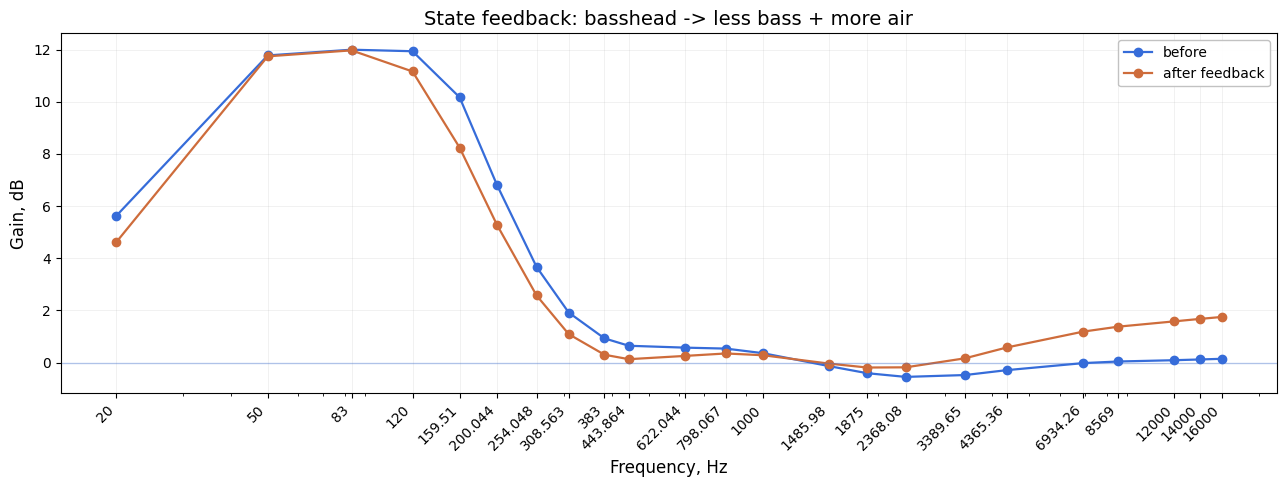

,stage,sub_bass,bass,lowmid,warmth,presence,clarity,air,brightness
0,before,1.65,1.45,-0.25,0.15,-0.200,0.100,0.250,-0.350
1,after,1.49,1.23,-0.30,0.15,-0.186,0.156,0.404,-0.186


In [4]:
state = init_preference_state(dim=8, init_std=0.6)
state.z_mean = CONTRACT_ARCHETYPES_8D["basshead"].copy()

state_after = apply_feedback_to_state(state, "too_much_bass", strength=1.0)
state_after = apply_feedback_to_state(state_after, "more_air", strength=0.7)

curves = {
    "before": mapper.map_one(state.z_mean),
    "after feedback": mapper.map_one(state_after.z_mean),
}
plot_eq_curves(curves, title="State feedback: basshead -> less bass + more air")
savefig("v6_contract_state_feedback.png")
plt.show()

pd.DataFrame([
    {"stage": "before", **{name: float(v) for name, v in zip(FEATURE_NAMES_8D, state.z_mean)}},
    {"stage": "after", **{name: float(v) for name, v in zip(FEATURE_NAMES_8D, state_after.z_mean)}},
])